In [1]:
import yaml
import matplotlib.pyplot as plt

# Dane wejściowe

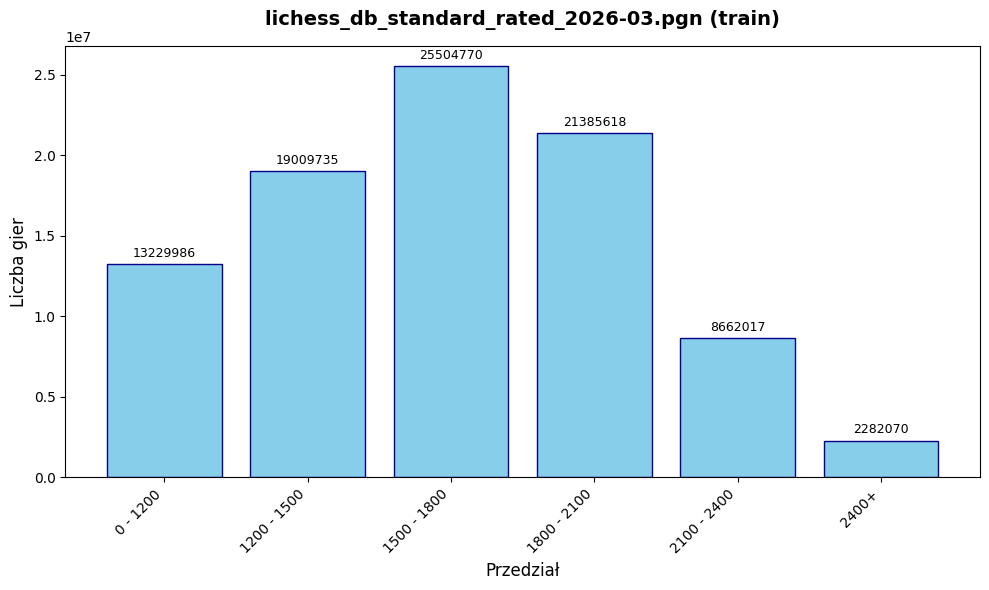

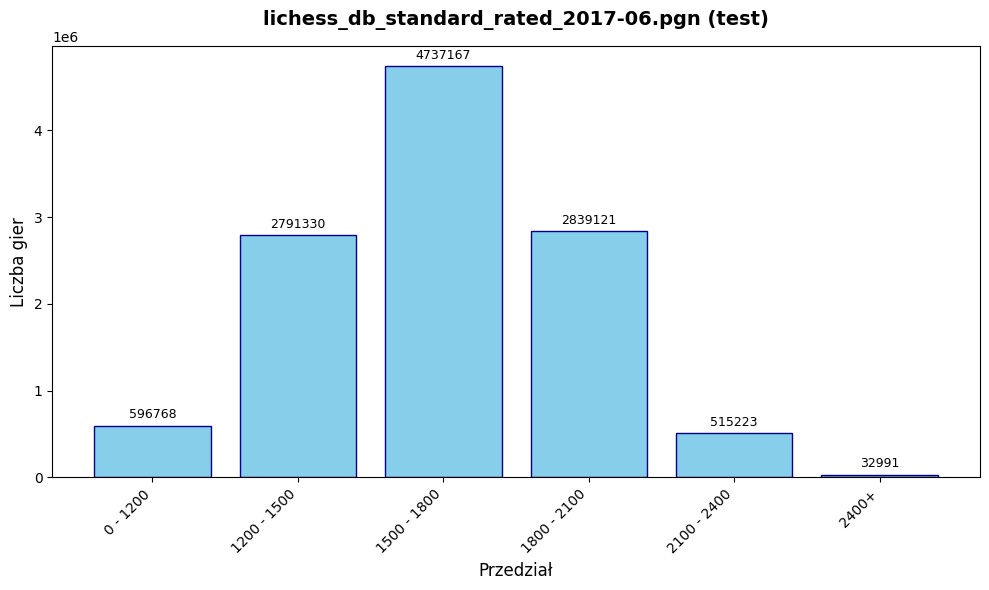

In [ ]:


# Define the path to your YAML file
yaml_file_paths = ['/home/adamz/Documents/praca-magisterska/graphs/split/data_test.yml',
                  '/home/adamz/Documents/praca-magisterska/graphs/split/data_train.yml']

for yaml_file_path in yaml_file_paths:

	# Open and parse the YAML file
	with open(yaml_file_path, 'r') as file:
		data = yaml.safe_load(file)

	# Extract the title and the breakdown data
	chart_title = data.get('file', 'Game Distribution')
	bucket_data = data.get('Breakdown by bucket', {})

	# In Python 3.7+, dictionary insertion order is preserved by default,
	# so converting directly to lists keeps the original file order.
	buckets = list(bucket_data.keys())
	counts = list(bucket_data.values())

	# Use subplots to set up dimensions safely
	fig, ax = plt.subplots(figsize=(10, 6))

	# Generate vertical bars using ax.bar
	bars = ax.bar(buckets, counts, color='skyblue', edgecolor='darkblue')

	# Add values above each vertical bar for clarity
	ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)

	# Set titles and axis labels
	ax.set_title(chart_title, fontsize=14, fontweight='bold', pad=15)
	ax.set_ylabel("Liczba gier", fontsize=12)
	ax.set_xlabel("Przedział", fontsize=12)

	# Rotate x-axis labels by 45 degrees and align them to prevent overlapping
	plt.xticks(rotation=45, ha='right')

	# Automatically adjust the padding so the rotated labels are completely visible
	plt.tight_layout()


	# Save the updated plot
	plt.savefig(f'bucket_distribution {chart_title}.png', dpi=300)

# błąd uczenia

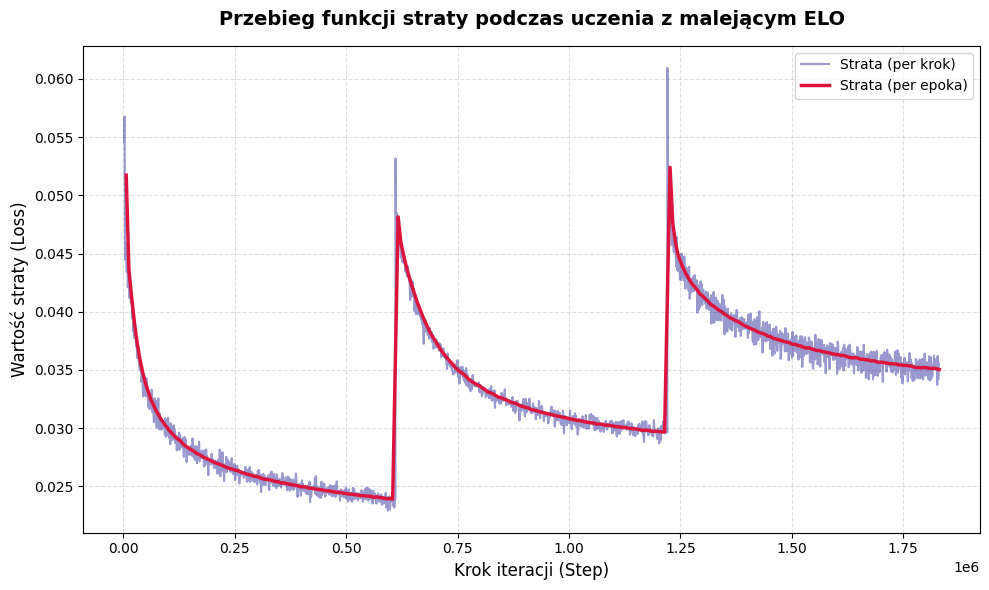

In [2]:
import io
import matplotlib.pyplot as plt
import pandas as pd

# Twoje dane CSV jako ciąg znaków (w realnym scenariuszu zamień na ścieżkę do pliku)
csv_data = "/home/adamz/Documents/praca-magisterska/graphs/train/reverse/metrics_joined.csv"

# Wczytanie danych (jeśli czytasz z pliku, użyj: pd.read_csv('sciezka_do_pliku.csv'))
df = pd.read_csv(csv_data)

# Przygotowanie czystych serii danych (odrzucenie NaN)
df_step = df.dropna(subset=["train_loss"])
df_epoch = df.dropna(subset=["train_loss_epoch"])

# Setup wykresu
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Linia kroków: dodany parametr alpha=0.4 dla przezroczystości
ax.plot(
    df_step["step"],
    df_step["train_loss"],
    color="darkblue",
    # marker="o",
    linewidth=1.5,
    markersize=4,
    alpha=0.4,
    label="Strata (per krok)",
)

# 2. Linia epok: zmienione z scatter na plot, by linia była ciągła
ax.plot(
    df_epoch["step"],
    df_epoch["train_loss_epoch"],
    color="crimson",
    # marker="X",
    linewidth=2.5,
    markersize=8,
    label="Strata (per epoka)",
)

# Stylistyka i opisy
ax.set_title(
    "Przebieg funkcji straty podczas uczenia z malejącym ELO",
    fontsize=14,
    fontweight="bold",
    pad=15,  
)
ax.set_ylabel("Wartość straty (Loss)", fontsize=12)
ax.set_xlabel("Krok iteracji (Step)", fontsize=12)

# Dodatki graficzne
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=10, loc="upper right")

plt.tight_layout()
plt.savefig("training_loss_continuous.png", dpi=300)

# Ewaluacja ELO

In [ ]:
import json
import matplotlib.pyplot as plt

RESULTS_JSON = '/home/adamz/Documents/praca-magisterska/graphs/elo/tournament_results_adjacent_research.json'
TITLE = 'Różnica w rankingu ELO pomiędzy kolejnymi epokami (research)'

with open(RESULTS_JSON, 'r') as f:
    data = json.load(f)

# Handle both JSON list [ {...}, {...} ] and JSON dict { "key": {...} }
matches = data if isinstance(data, list) else list(data.values())

steps = []
elo_diffs = []
error_margins = []
epochs = []

for entry in matches:
    # Extract engine names from "match": "epoch_10_vs_epoch_20"
    match_str = entry.get("match", "A_vs_B")
    if "_vs_" in match_str:
        engine_a, engine_b = match_str.split("_vs_")
    else:
        engine_a = entry.get("engine_a", "A")
        engine_b = entry.get("engine_b", "B")

    label_a = engine_a.replace("epoch_", "Ep ").replace("_", " ").title()
    label_b = engine_b.replace("epoch_", "Ep ").replace("_", " ").title()

    steps.append(f"{label_a} $\\rightarrow$ {label_b}")

    metrics = entry.get("metrics") or entry.get("match_metrics", {})
    
    # Invert sign so positive values mean Engine B is stronger than Engine A (forward progress)
    reported_diff = metrics.get("elo_diff", 0.0)
    elo_diffs.append(-reported_diff)
    error_margins.append(metrics.get("error_margin", 0.0))

    if not epochs:
        epochs.append(label_a)
    epochs.append(label_b)

# Compute cumulative progression
cumulative_elo = [0]
for diff in elo_diffs:
    cumulative_elo.append(cumulative_elo[-1] + diff)

num_items = len(steps)


# =====================================================================
# GRAPH 1: SUCCESSIVE ELO DIFFERENCES
# =====================================================================
fig, ax1 = plt.subplots(figsize=(10, 4.5))

colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in elo_diffs]

bars = ax1.bar(
    steps, elo_diffs, color=colors, edgecolor='none', width=0.6,
    yerr=error_margins, capsize=2,
    error_kw={'ecolor': '#7f8c8d', 'linewidth': 0.8, 'alpha': 0.7}
)

ax1.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)
ax1.set_title(TITLE, fontsize=11, fontweight='bold', pad=10)
ax1.set_ylabel('Przyrost ELO (B vs A)', fontsize=9)
ax1.grid(axis='y', linestyle=':', alpha=0.4)

ax1.tick_params(axis='x', rotation=70, labelsize=8)
ax1.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('elo_differences.png', dpi=300)
plt.close()


# =====================================================================
# GRAPH 2: CUMULATIVE ELO PROGRESSION
# =====================================================================
fig, ax2 = plt.subplots(figsize=(10, 4))

ax2.plot(
    epochs, cumulative_elo, marker='o', linestyle='-', color='#3498db',
    linewidth=1.5, markersize=3.5
)

ax2.set_title('Kumulatywny postęp ELO (research)', fontsize=11, fontweight='bold', pad=10)
ax2.set_ylabel('Względny ranking ELO (od Ep 0/początkowej)', fontsize=9)
ax2.grid(linestyle=':', alpha=0.4)

ax2.tick_params(axis='x', rotation=70, labelsize=8)
ax2.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('elo_cumulative_progression.png', dpi=300)
plt.close()

print(f"Successfully generated 2 compact graphs across {num_items} progression steps!")

Successfully generated 2 compact graphs across 29 progression steps!
